In [68]:
import pandas as pd
import glob
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes  import MultinomialNB
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [21]:
import os
print(os.getcwd())

C:\Windows\System32


In [22]:
%pwd

'C:\\Windows\\System32'

In [23]:
files = glob.glob('anaconda_projects/youtube-dataset/*.csv')
files


['anaconda_projects/youtube-dataset\\Youtube01.csv',
 'anaconda_projects/youtube-dataset\\Youtube02.csv',
 'anaconda_projects/youtube-dataset\\Youtube03.csv',
 'anaconda_projects/youtube-dataset\\Youtube04.csv',
 'anaconda_projects/youtube-dataset\\Youtube05.csv']

In [24]:
all_df = []
for i in files:
    all_df.append(pd.read_csv(i).drop(['COMMENT_ID', 'AUTHOR', 'DATE'], axis=1))

In [25]:
all_df[0]

,CONTENT,CLASS
0,"Huh, anyway check out this you[tube] channel: ...",1
1,Hey guys check out my new channel and our firs...,1
2,just for test I have to say murdev.com,1
3,watch?v=vtaRGgvGtWQ Check this out .﻿,1
4,"Hey, check out my new website!! This site is a...",1
...,...,...
344,How can this have 2 billion views when there's...,0
345,I don't now why I'm watching this in 2014﻿,0
346,subscribe to me for call of duty vids and give...,1
347,hi guys please my android photo editor downloa...,1


In [26]:
data = pd.concat(all_df,axis=0,ignore_index=True)

In [27]:
data

,CONTENT,CLASS
0,"Huh, anyway check out this you[tube] channel: ...",1
1,Hey guys check out my new channel and our firs...,1
2,just for test I have to say murdev.com,1
3,watch?v=vtaRGgvGtWQ Check this out .﻿,1
4,"Hey, check out my new website!! This site is a...",1
...,...,...
1950,I love this song because we sing it at Camp al...,0
1951,I love this song for two reasons: 1.it is abou...,0
1952,wow,0
1953,Shakira u are so wiredo,0


In [28]:
data.isnull().sum()

CONTENT    0
CLASS      0
dtype: int64

In [29]:
data['CLASS'].value_counts()

1    1004
0     951
Name: CLASS, dtype: int64

sample 1

In [39]:
message_sample=['This is a dog']
vectorizer_sample=CountVectorizer()
vectorizer_sample.fit(message_sample)
vectorizer_sample.transform(message_sample).toarray

<bound method _cs_matrix.toarray of <1x3 sparse matrix of type '<class 'numpy.int64'>'
	with 3 stored elements in Compressed Sparse Row format>>

In [40]:
vectorizer_sample.get_feature_names_out()

array(['dog', 'is', 'this'], dtype=object)

In [41]:
vectorizer_sample.transform(['This is a cat']).toarray

<bound method _cs_matrix.toarray of <1x3 sparse matrix of type '<class 'numpy.int64'>'
	with 2 stored elements in Compressed Sparse Row format>>

sample 2


In [45]:
message_sample2=['This is a dog and that is a dog','This is a cat']
vectorizer_sample2=CountVectorizer()
vectorizer_sample2.fit_transform(message_sample2).toarray()

array([[1, 0, 2, 2, 1, 1],
       [0, 1, 0, 1, 0, 1]], dtype=int64)

In [46]:
vectorizer_sample2.get_feature_names_out()

array(['and', 'cat', 'dog', 'is', 'that', 'this'], dtype=object)

preprocessing

Defining the inputs and the target. Creating the train-test split.

In [48]:
inputs = data['CONTENT']
target = data['CLASS']

In [49]:
x_train, x_test, y_train, y_test = train_test_split(inputs, target,
                                                    test_size = 0.2,
                                                    random_state = 365,
                                                    stratify = target)

In [50]:
y_train.value_counts(normalize = True)

1    0.513427
0    0.486573
Name: CLASS, dtype: float64

In [51]:
y_test.value_counts(normalize = True)

1    0.514066
0    0.485934
Name: CLASS, dtype: float64

Tokenizing the YouTube comments

In [52]:
vectorizer = CountVectorizer()

In [53]:
x_train_transf = vectorizer.fit_transform(x_train)
x_test_transf = vectorizer.transform(x_test)

In [54]:
x_train_transf.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [55]:
x_train_transf.shape


(1564, 3925)

In [57]:
x_test_transf.shape

(391, 3925)

performing the classification

In [60]:
clf = MultinomialNB()

In [61]:
clf.fit(x_train_transf, y_train)

MultinomialNB()

In [62]:
clf.get_params()

{'alpha': 1.0, 'class_prior': None, 'fit_prior': True}

quantify the model's performance

In [64]:
y_test_pred = clf.predict(x_test_transf)

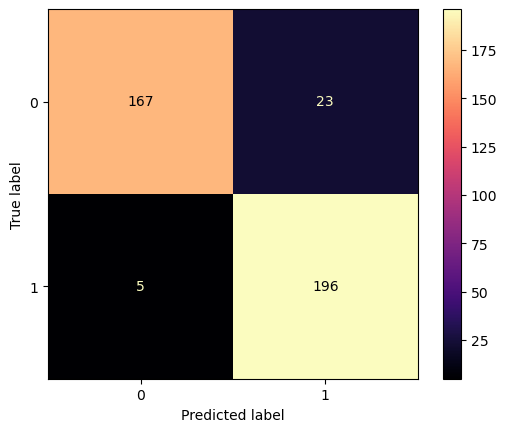

In [65]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_test_pred,
    labels = clf.classes_,
    cmap = 'magma'
);

In [67]:
print(classification_report(y_test,y_test_pred, target_names=['Ham','Spam']))

              precision    recall  f1-score   support

         Ham       0.97      0.88      0.92       190
        Spam       0.89      0.98      0.93       201

    accuracy                           0.93       391
   macro avg       0.93      0.93      0.93       391
weighted avg       0.93      0.93      0.93       391

